# Medicare Rate and Utilization Analysis
### A Case Study in Payment Variation Across Providers, Procedures, and Geographies

**Author:** Sridharan Gopalsamy Ramaswamy  
**Date:** April 2026  
**Data:** CMS Medicare Provider Utilization and Payment Data, Calendar Year 2022  

---

## Executive Summary

This analysis examines Medicare payment patterns across 3,015 inpatient hospitals and 1.15 million physician providers using CMS public use files. Three findings stand out for anyone working in payer strategy, provider contracting, or health economics:

1. **Hospitals charge 5.4x what Medicare pays** (median), but this ratio varies from 1.2x in Maryland to 10.7x in Nevada, a 9.5x spread that reflects state-level regulatory and market dynamics.
2. **Septicemia dominates inpatient volume**, accounting for 550K discharges (11% of all Medicare inpatient stays), while heart transplants lead in cost at ~$295K per case.
3. **Physician markup ratios vary sharply by specialty**, with certain specialties billing 4-5x the Medicare allowed amount, signaling where payer-provider rate negotiations have the most room to move.

The "so what": these patterns are directly relevant to rate benchmarking, network adequacy modeling, and value-based contracting strategy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import Image, display, Markdown

plt.rcParams.update({
    'figure.facecolor': '#0F0F14',
    'axes.facecolor': '#0F0F14',
    'axes.edgecolor': '#2A2A35',
    'axes.labelcolor': '#E2E0E6',
    'text.color': '#E2E0E6',
    'xtick.color': '#9894A8',
    'ytick.color': '#9894A8',
    'grid.color': '#1E1E28',
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 150
})

PROCESSED = Path('../data/processed')
FIGURES = Path('../figures')

INDIGO = '#818CF8'
PINK = '#F472B6'
GREEN = '#10B981'
AMBER = '#F59E0B'
BLUE = '#3B82F6'

In [2]:
inp = pd.read_csv(PROCESSED / 'inpatient_clean.csv', dtype={'provider_zip': str})
phy = pd.read_csv(PROCESSED / 'physician_clean.csv', dtype={'provider_zip': str, 'hcpcs_code': str}, low_memory=False)

display(Markdown(f'''
| Metric | Inpatient | Physician |
|--------|-----------|----------|
| Records | {len(inp):,} | {len(phy):,} |
| Providers | {inp.provider_ccn.nunique():,} | {phy.npi.nunique():,} |
| Procedures | {inp.drg_code.nunique():,} DRGs | {phy.hcpcs_code.nunique():,} HCPCS |
| States | {inp.provider_state.nunique()} | {phy.provider_state.nunique()} |
| Median markup | {inp.markup_ratio.median():.2f}x | {phy.markup_ratio.median():.2f}x |
'''))


| Metric | Inpatient | Physician |
|--------|-----------|----------|
| Records | 145,742 | 9,755,020 |
| Providers | 3,015 | 1,148,808 |
| Procedures | 533 DRGs | 6,326 HCPCS |
| States | 51 | 61 |
| Median markup | 5.37x | 2.79x |


---
## 1. Where the volume is: top DRGs

Understanding which diagnoses drive the most inpatient volume matters for capacity planning, risk adjustment, and contract carve-outs. Septicemia alone represents over 10% of all Medicare inpatient discharges.

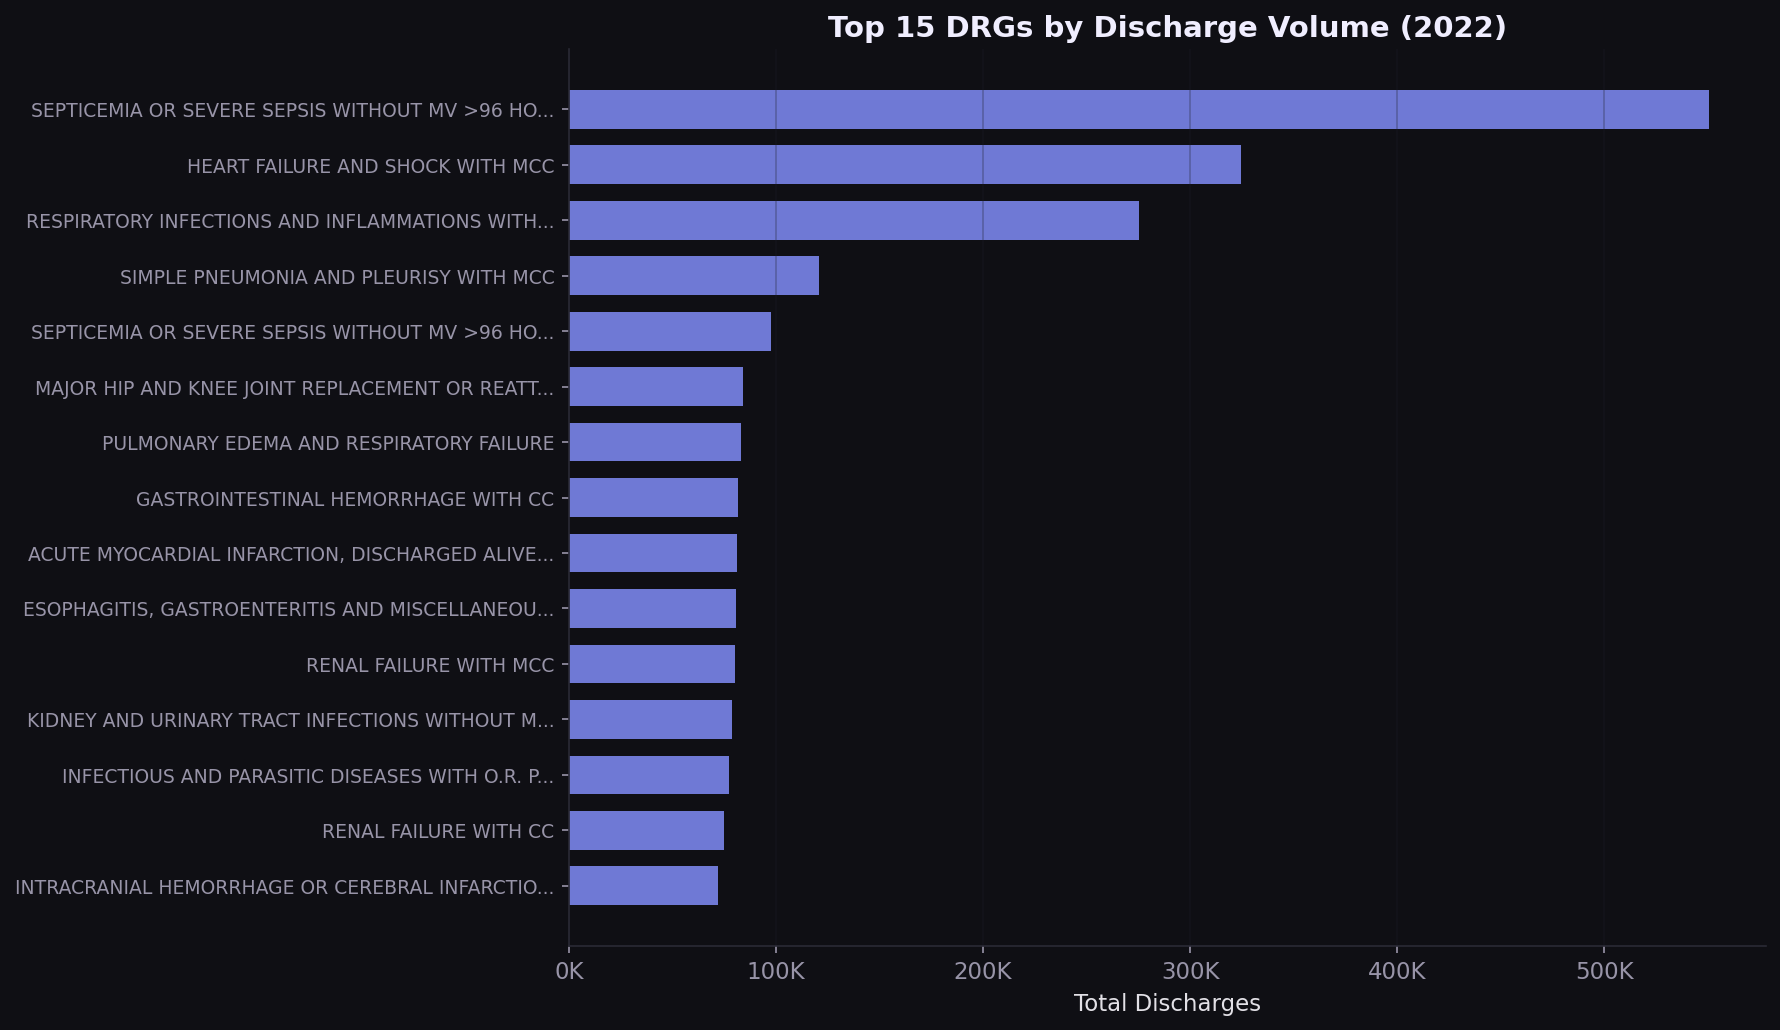

In [3]:
display(Image(filename=str(FIGURES / 'top15_drg_volume.png')))

**Takeaway for payer strategy:** The top 5 DRGs account for a disproportionate share of volume. Any value-based contract that doesn't explicitly address septicemia, heart failure, and respiratory infections is leaving the highest-volume conditions unmanaged.

---
## 2. Where the money goes: costliest DRGs

Volume tells one story; cost tells another. The costliest DRGs are surgical and transplant-related, with per-case payments that can exceed $100K.

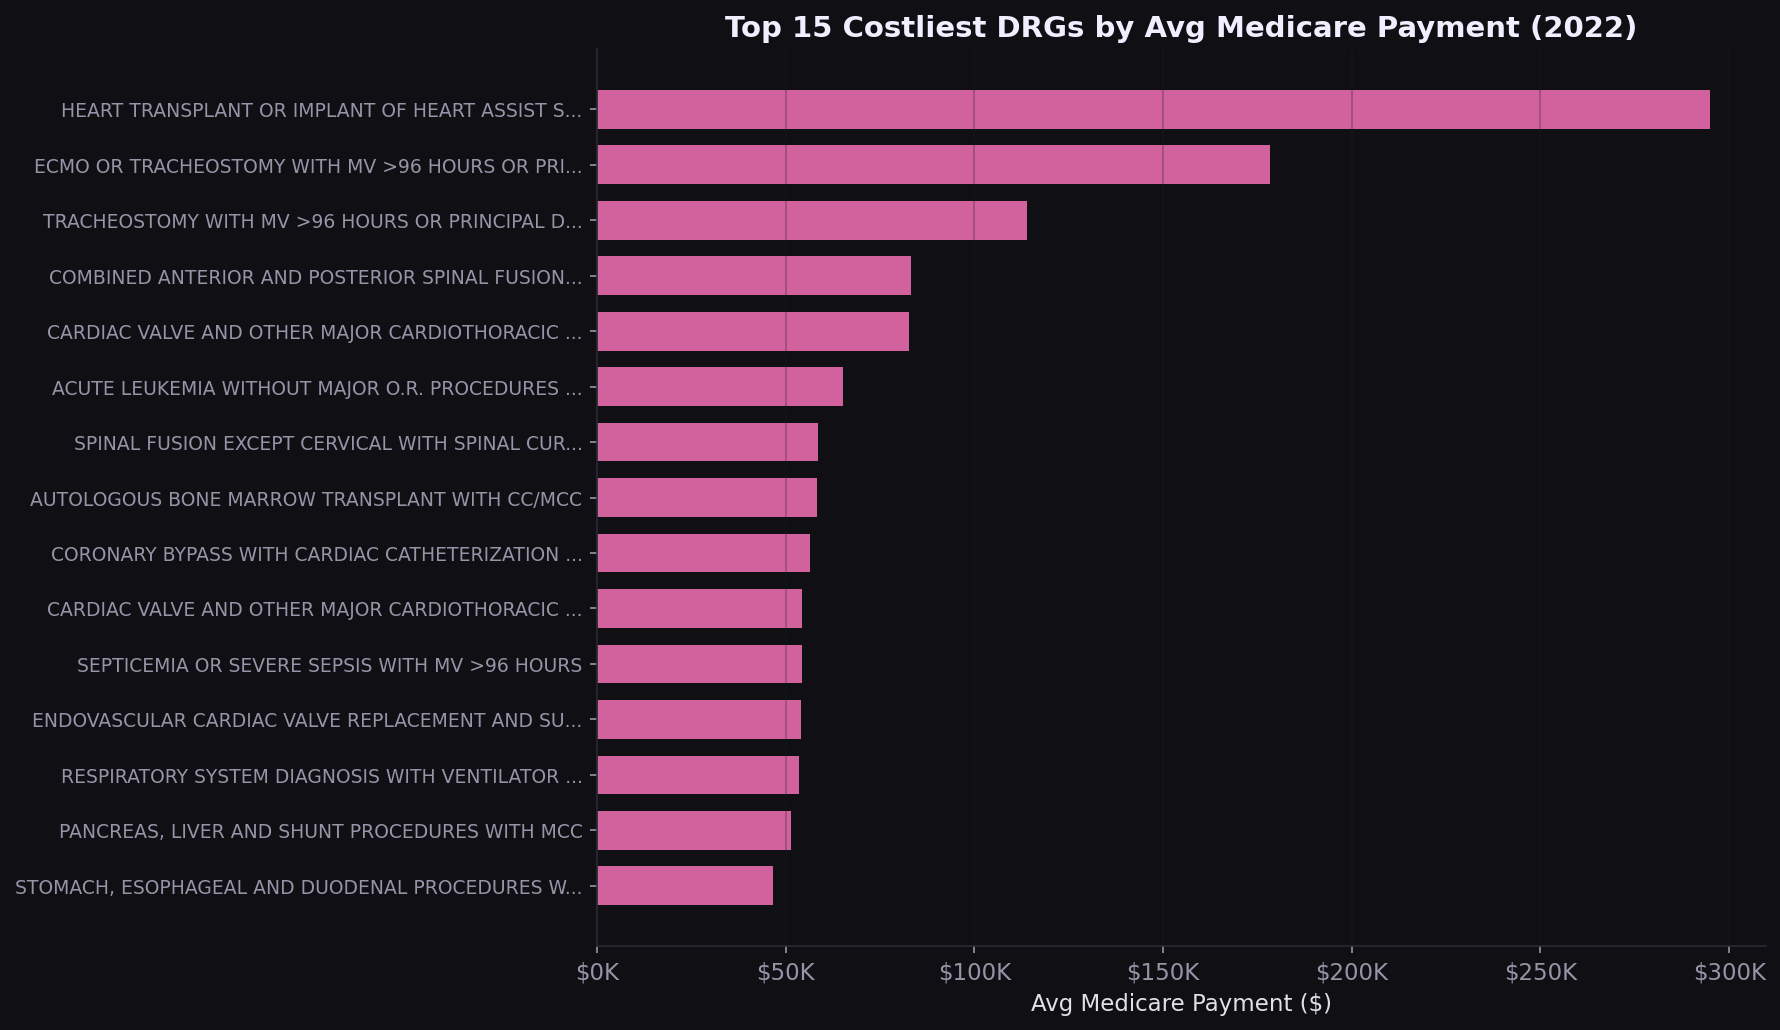

In [4]:
display(Image(filename=str(FIGURES / 'top15_drg_cost.png')))

**Takeaway:** Heart transplants and ECMO cases average $295K and $178K respectively. For commercial payers benchmarking against Medicare, these are the DRGs where a 10% rate difference translates to $20K-$30K per case.

---
## 3. The markup gap: what hospitals charge vs. what Medicare pays

The gap between submitted charges and actual Medicare payments is one of the most cited indicators of healthcare pricing opacity. Nationally, the median hospital charges 5.4x what Medicare ultimately pays.

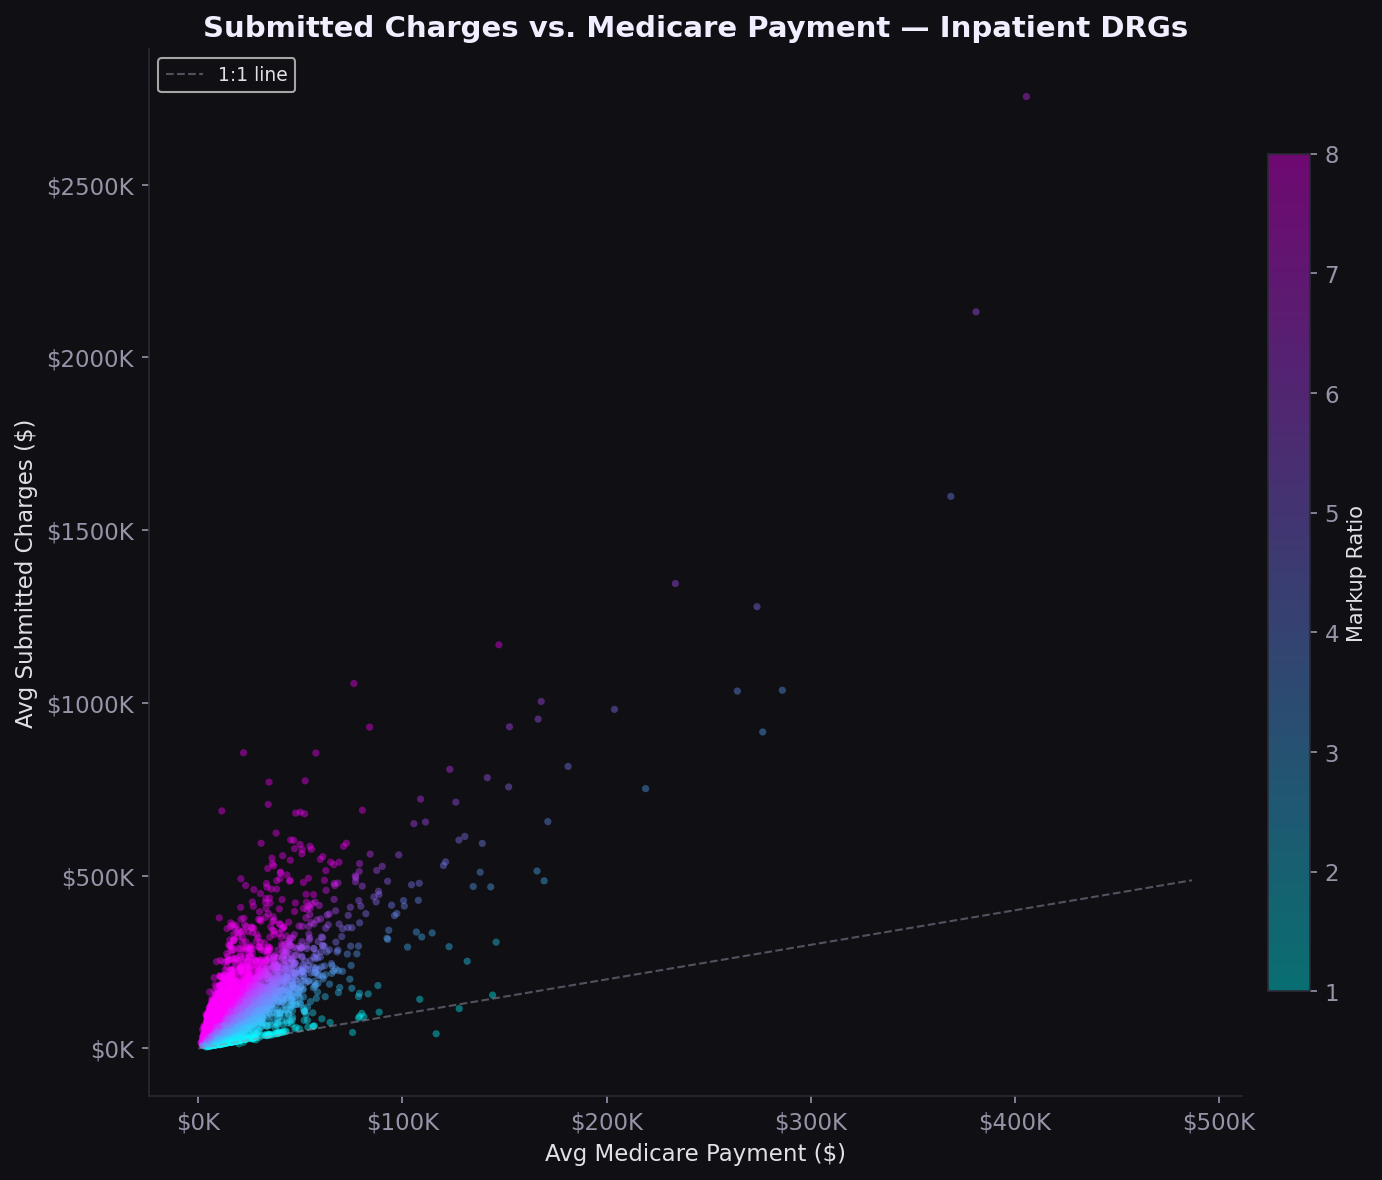

In [5]:
display(Image(filename=str(FIGURES / 'inpatient_charges_vs_payment.png')))

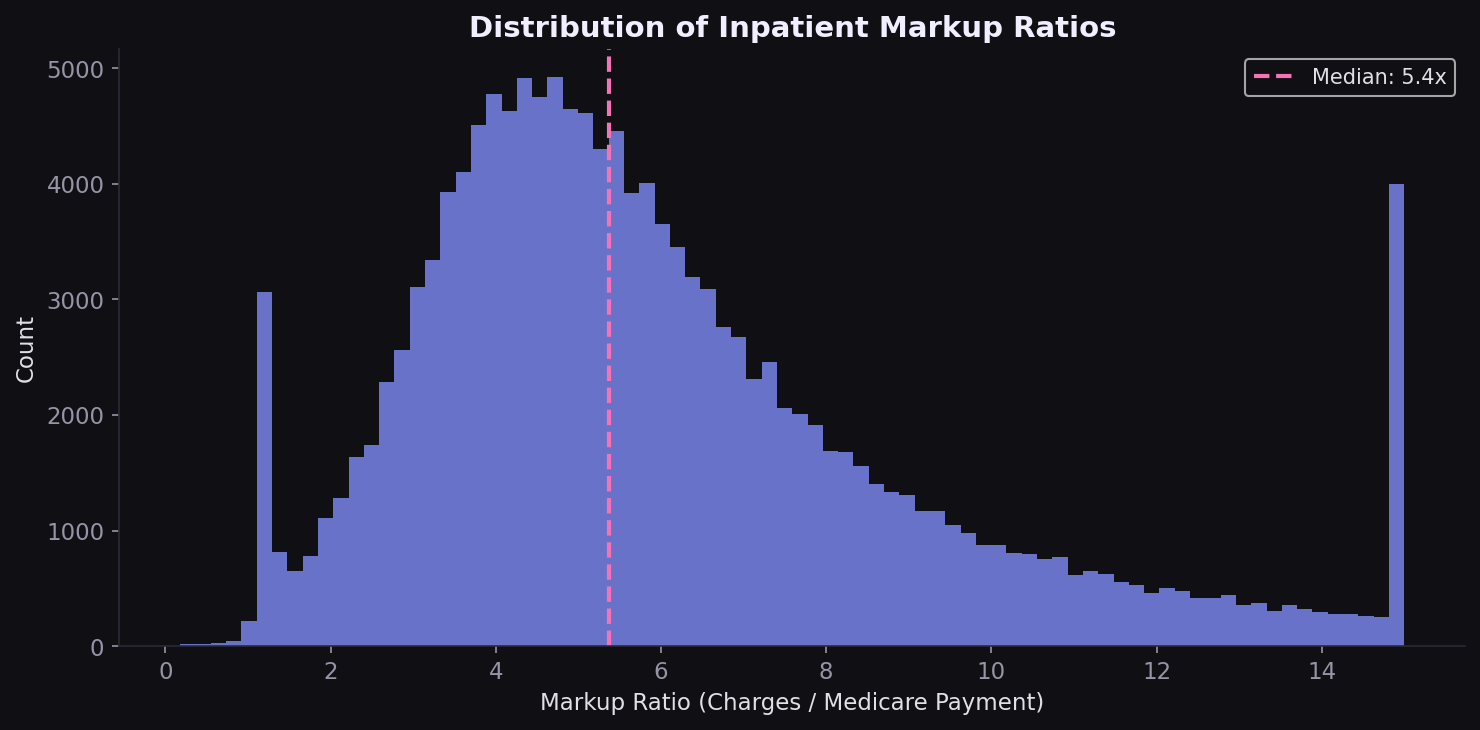

In [6]:
display(Image(filename=str(FIGURES / 'inpatient_markup_distribution.png')))

**Takeaway:** The scatter plot shows a clear nonlinear relationship: for higher-cost DRGs, the markup ratio compresses, while lower-cost procedures show the widest spread. The distribution is right-skewed, meaning a minority of hospitals charge 8-12x Medicare rates. This is the pricing signal that transparency tools like MyRateFinder aim to surface.

---
## 4. Geography matters: state-level markup variation

The 9.5x spread in median markup between Maryland (1.2x) and Nevada (10.7x) isn't random. Maryland operates an all-payer rate-setting system, which compresses the charge-to-payment gap by design. States without rate regulation show far higher markups.

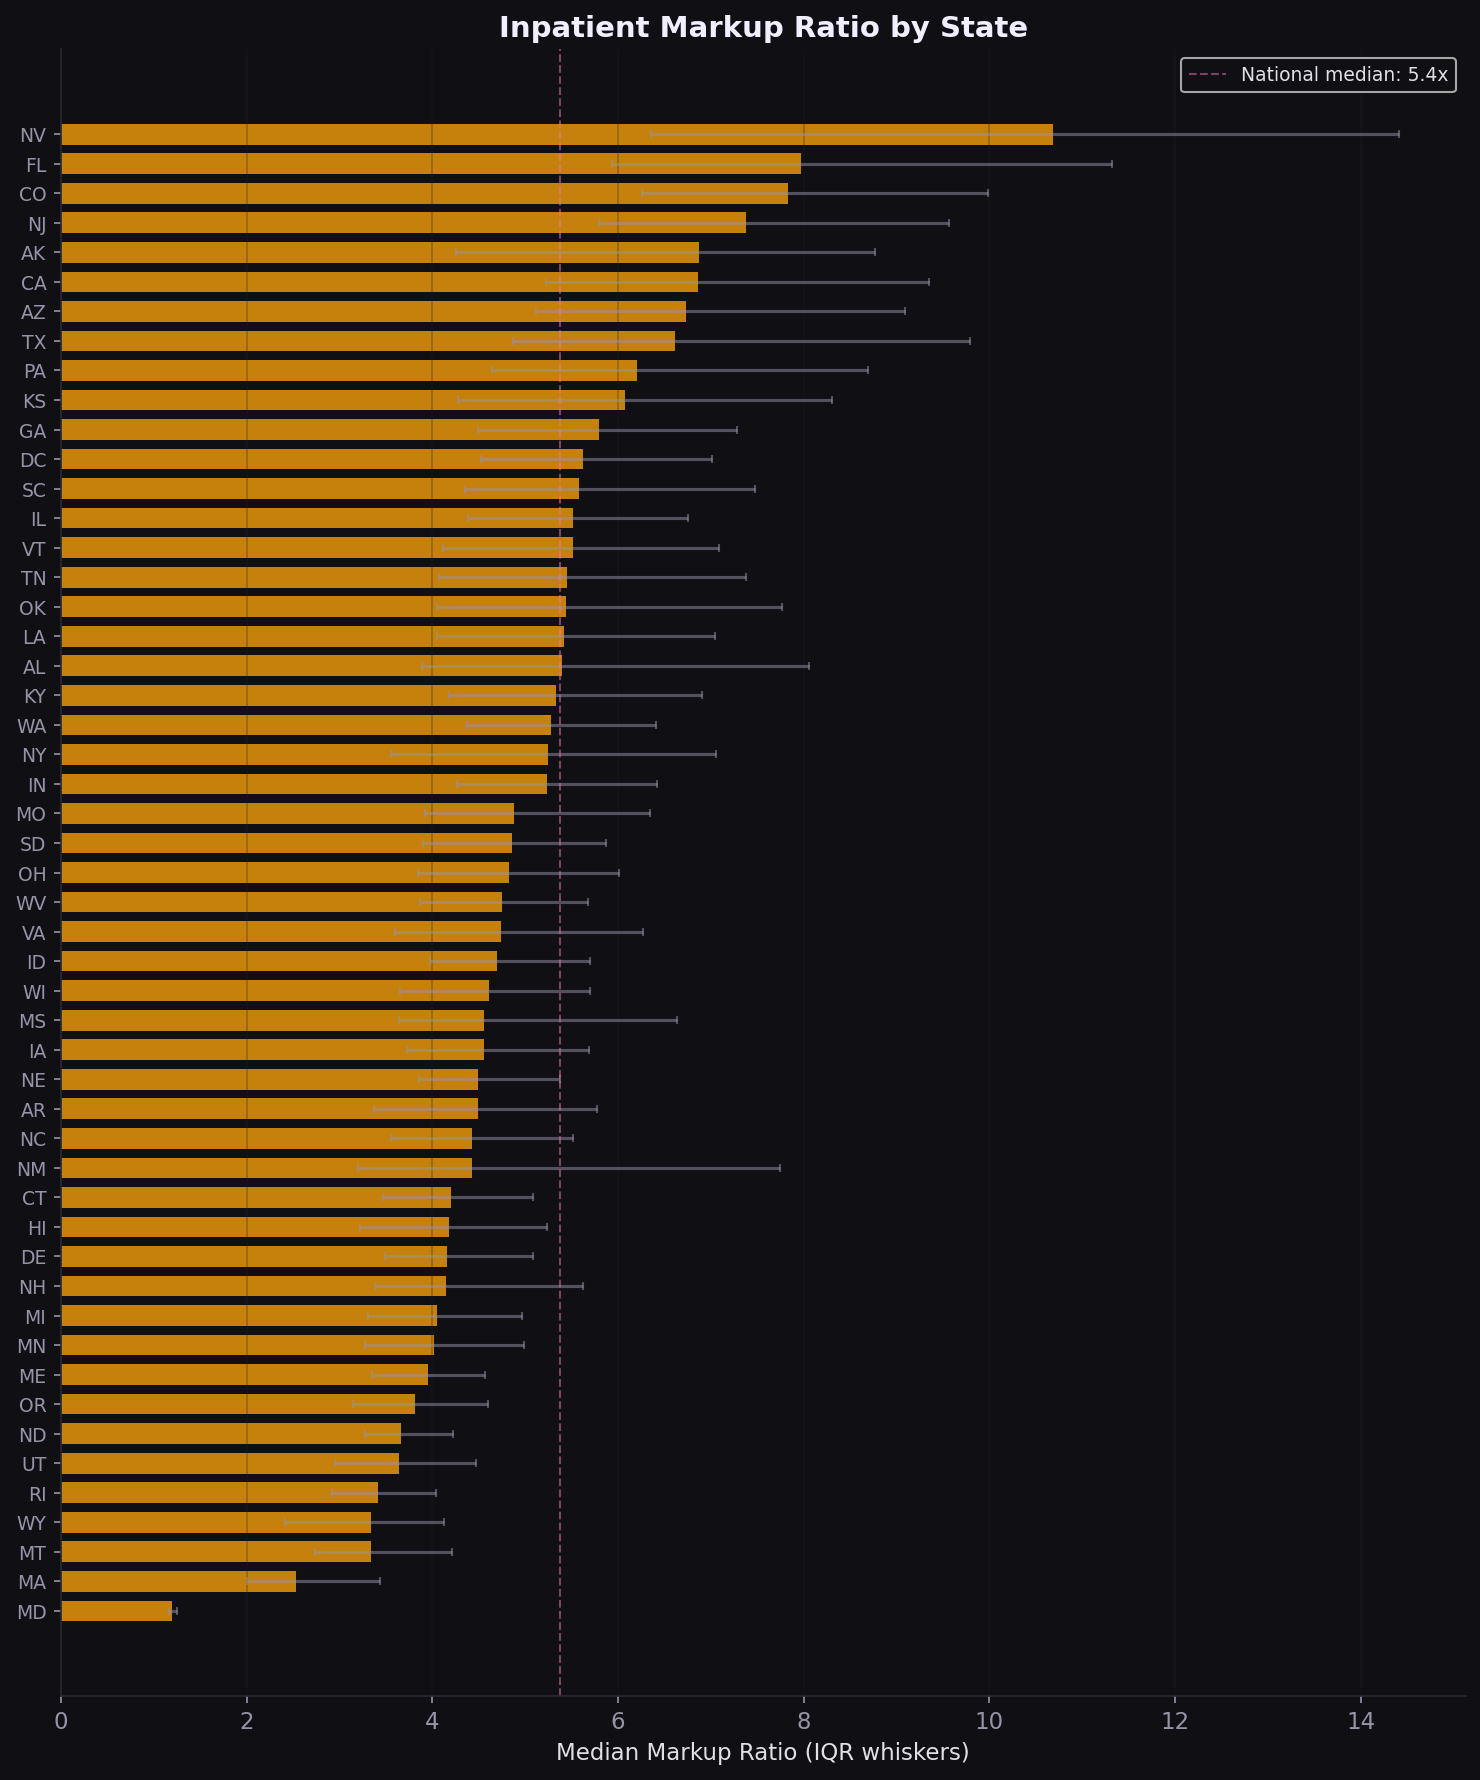

In [7]:
display(Image(filename=str(FIGURES / 'state_markup_variation.png')))

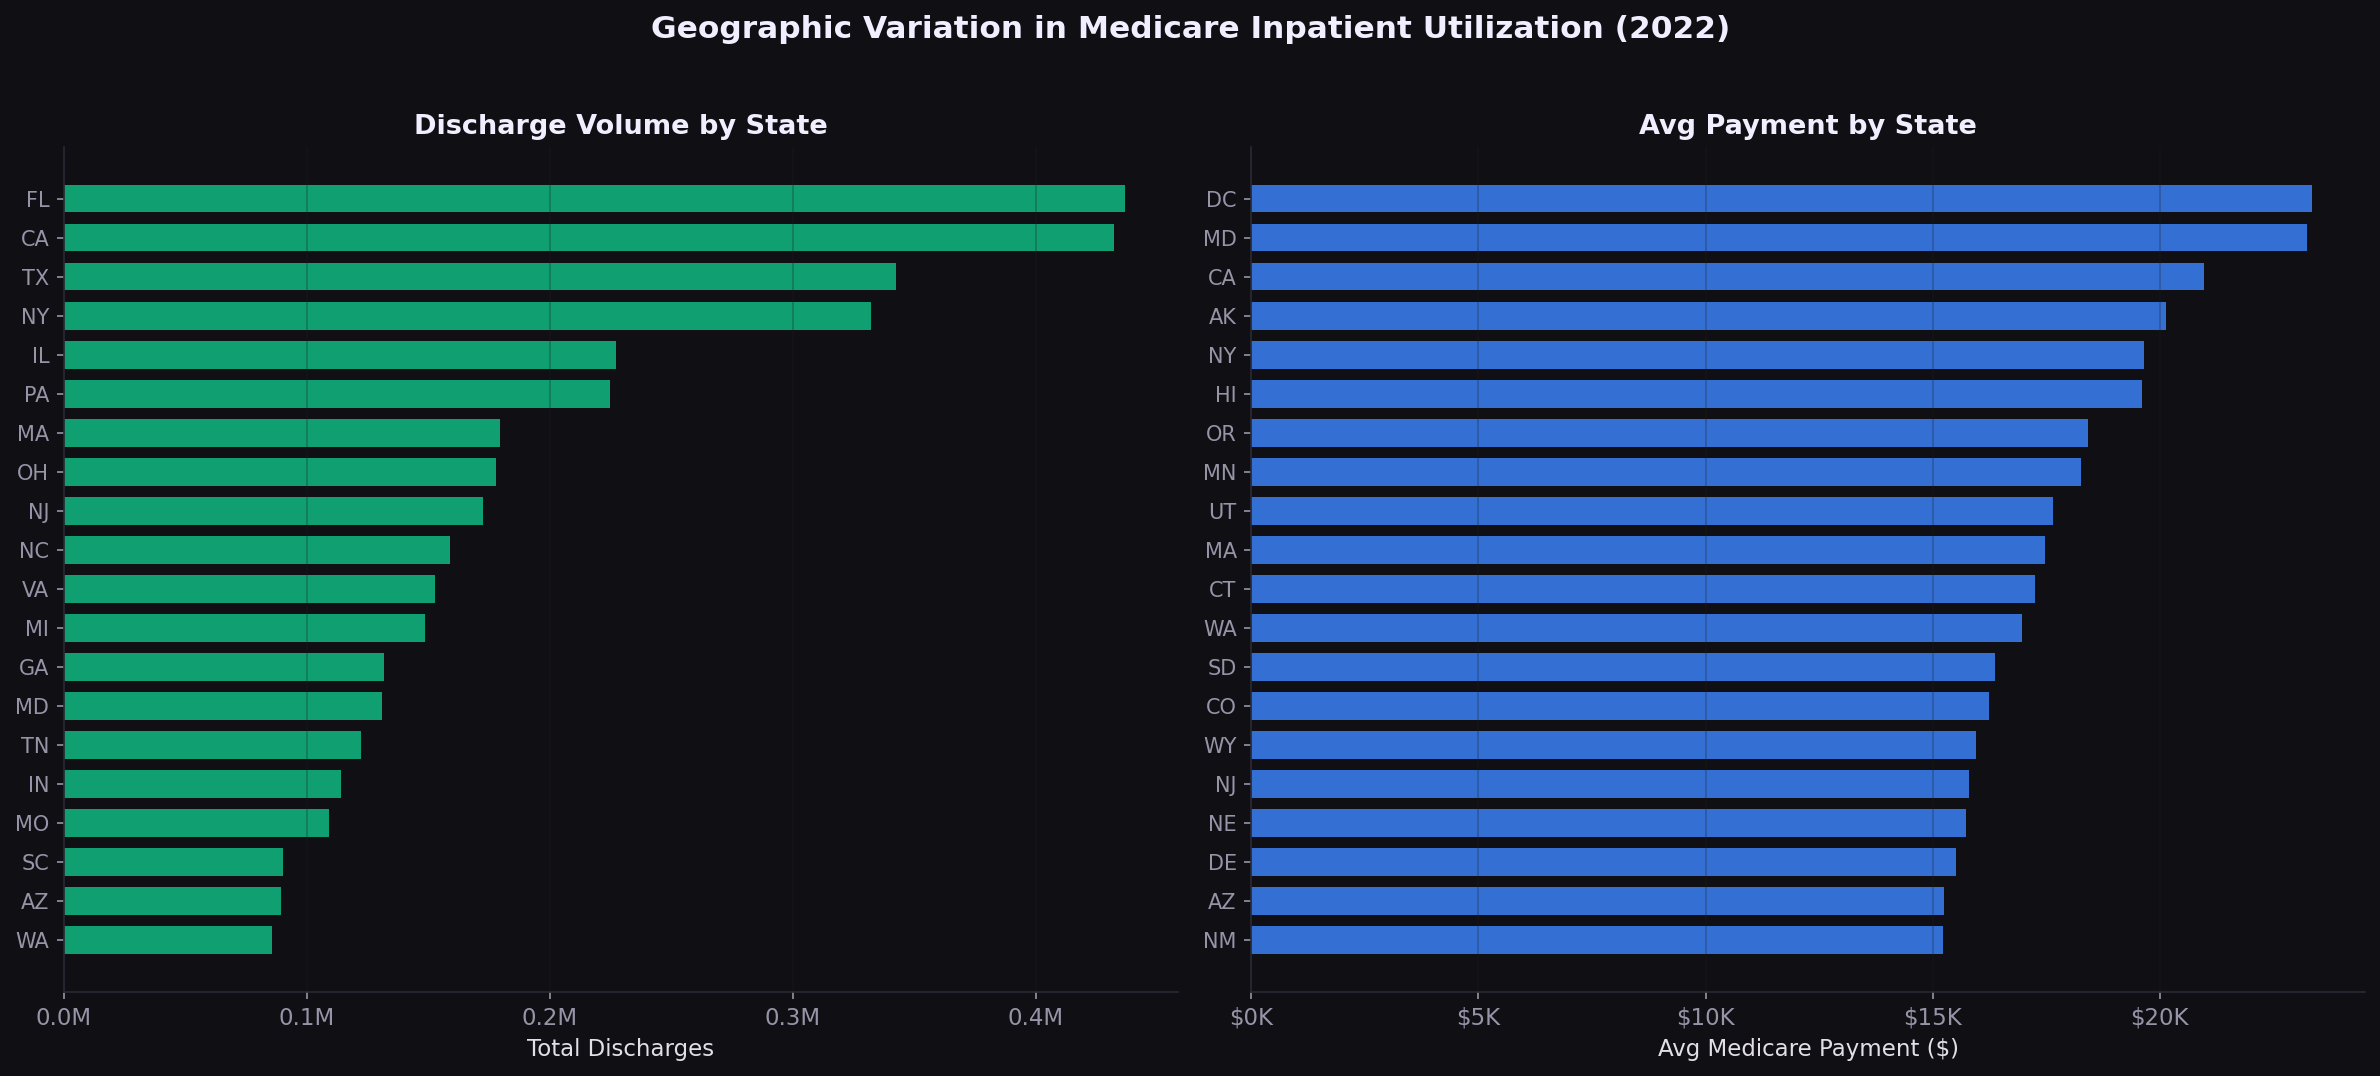

In [8]:
display(Image(filename=str(FIGURES / 'state_volume_payment.png')))

**Takeaway:** For payers operating across multiple states, geographic rate variation is a contracting lever. States like California, Texas, and Florida have high volume and above-median markups, making them priority markets for rate renegotiation. Maryland's compressed ratios demonstrate what regulatory intervention can achieve.

---
## 5. Payment variation within states

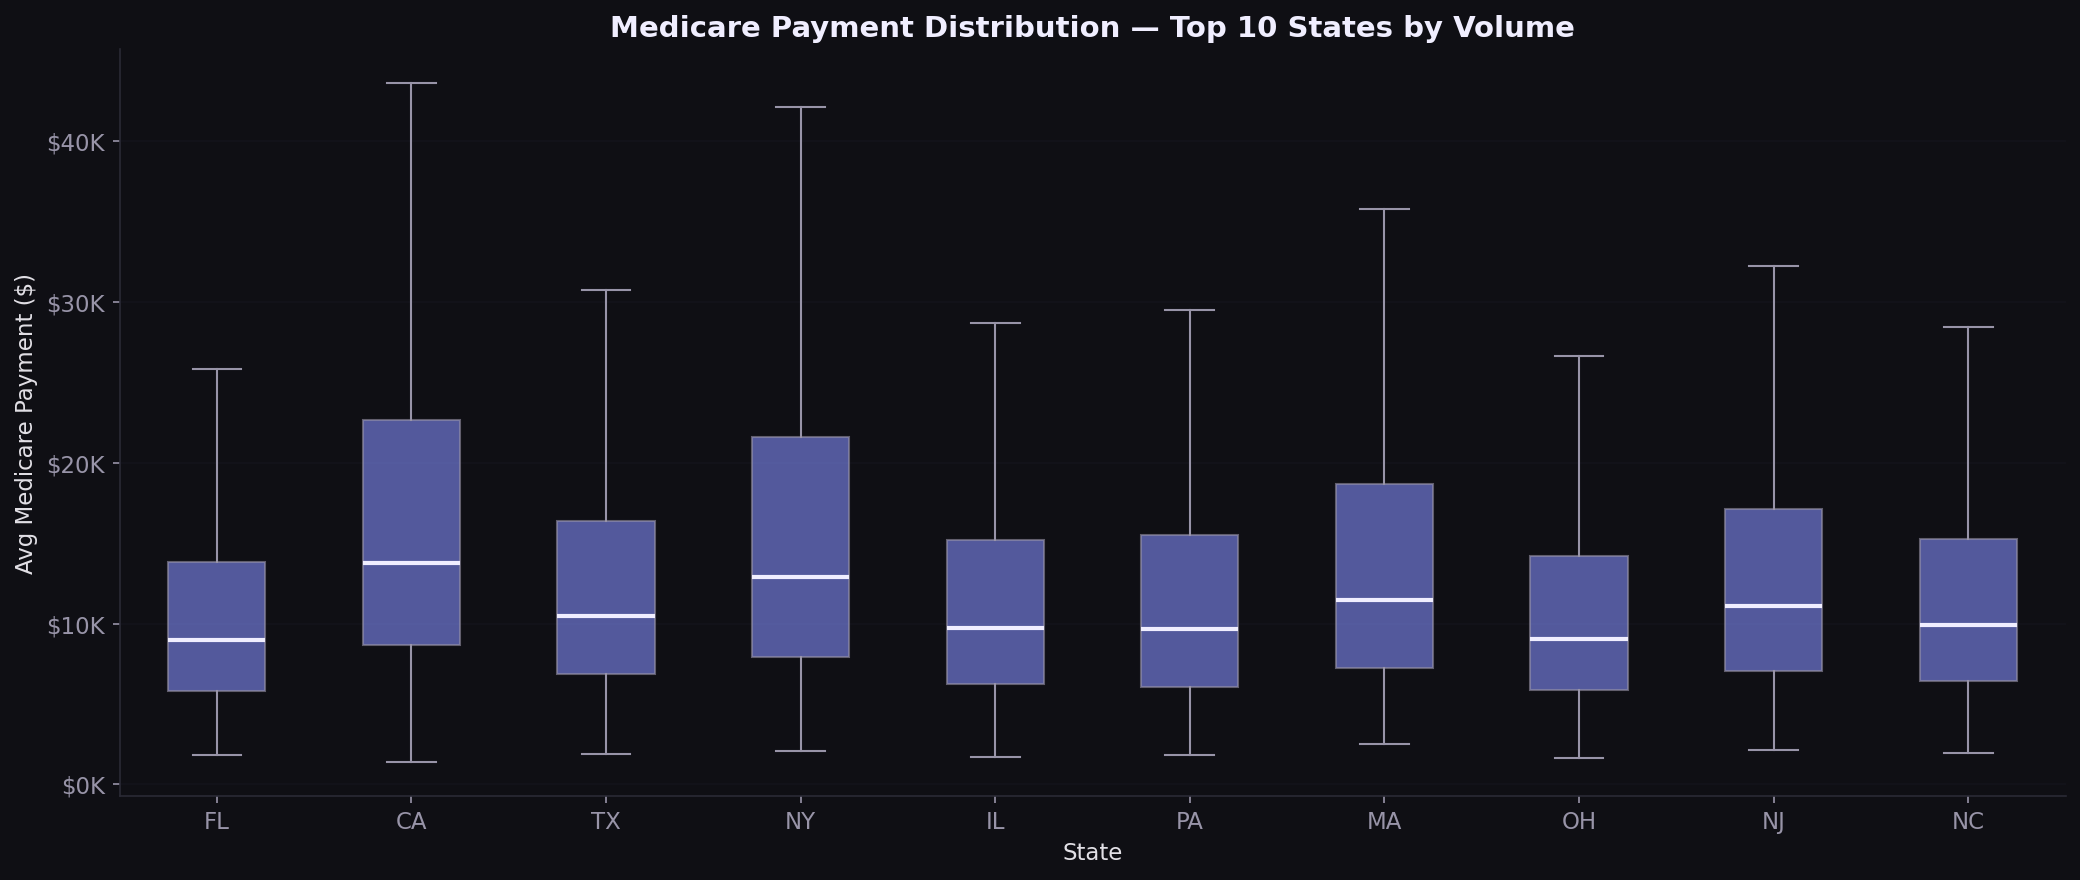

In [9]:
display(Image(filename=str(FIGURES / 'state_payment_boxplot.png')))

**Takeaway:** Even within the same state, Medicare payment varies substantially across providers and DRGs. This within-state spread suggests that network design and site-of-care steering could yield savings even without renegotiating rates.

---
## 6. Physician services: where volume and cost concentrate

On the outpatient side, clinical laboratory and hematology-oncology dominate service volume, while ambulatory surgical centers and cardiac surgery lead in per-service cost.

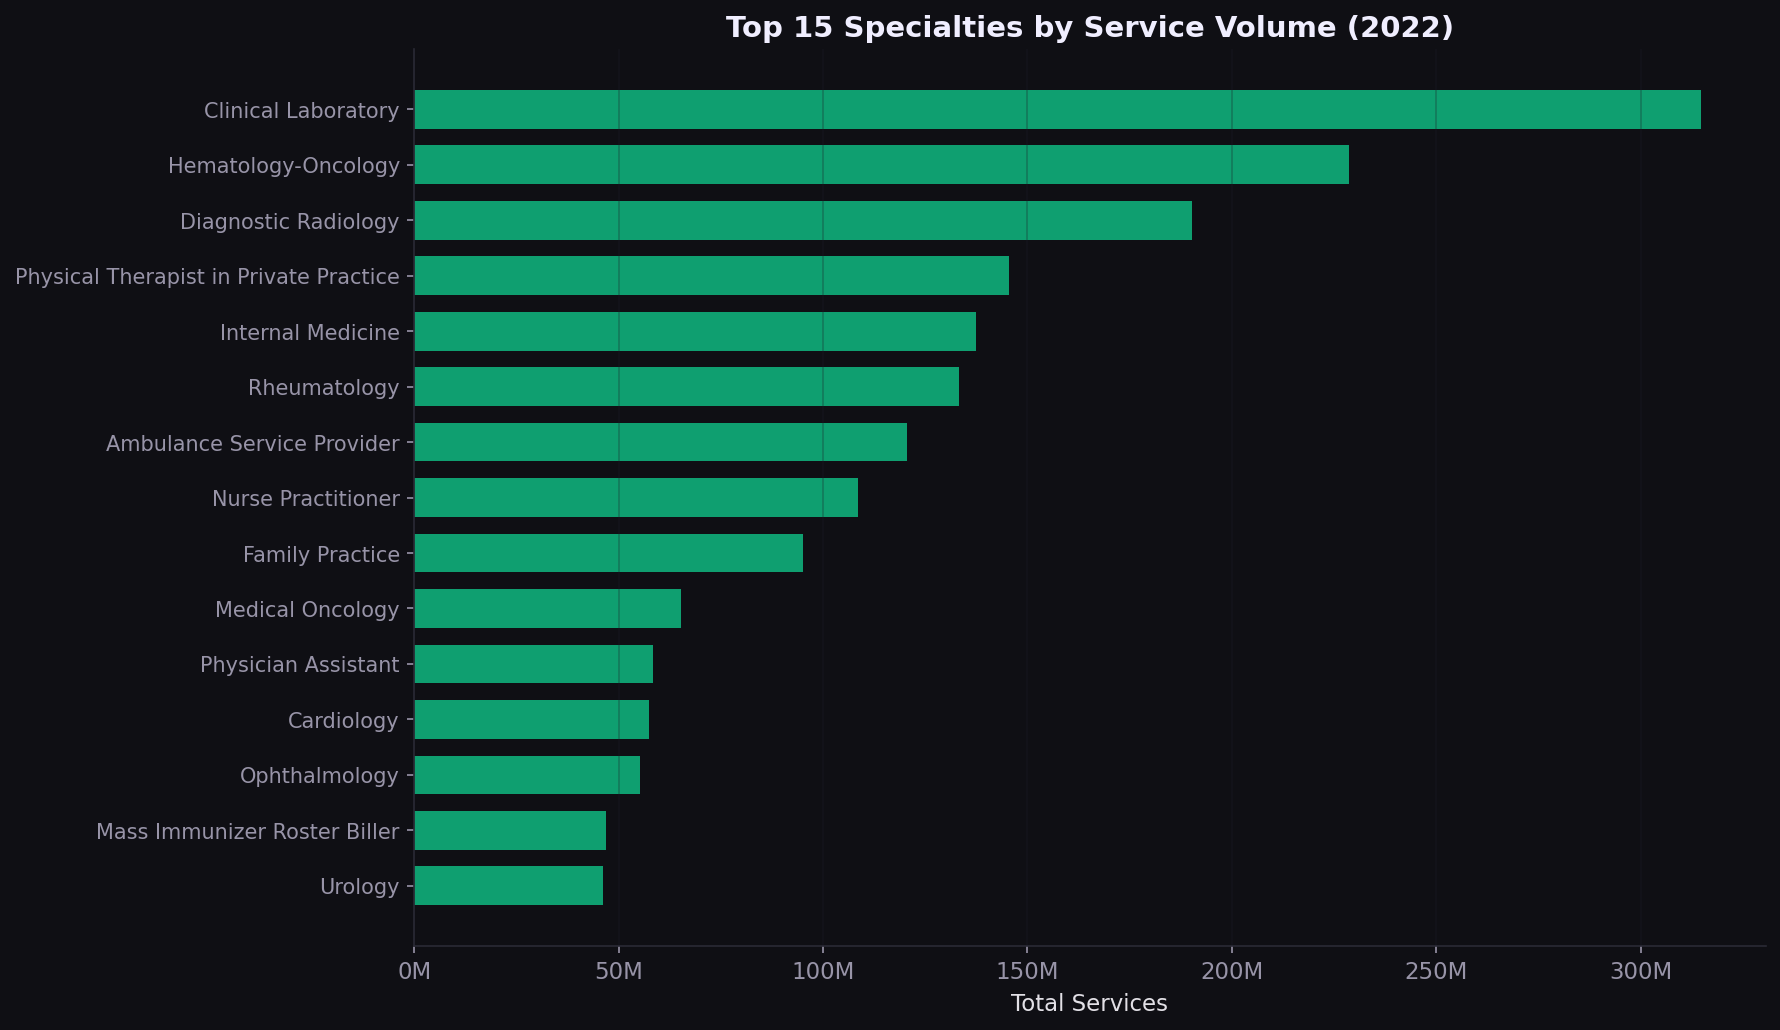

In [10]:
display(Image(filename=str(FIGURES / 'top15_specialty_volume.png')))

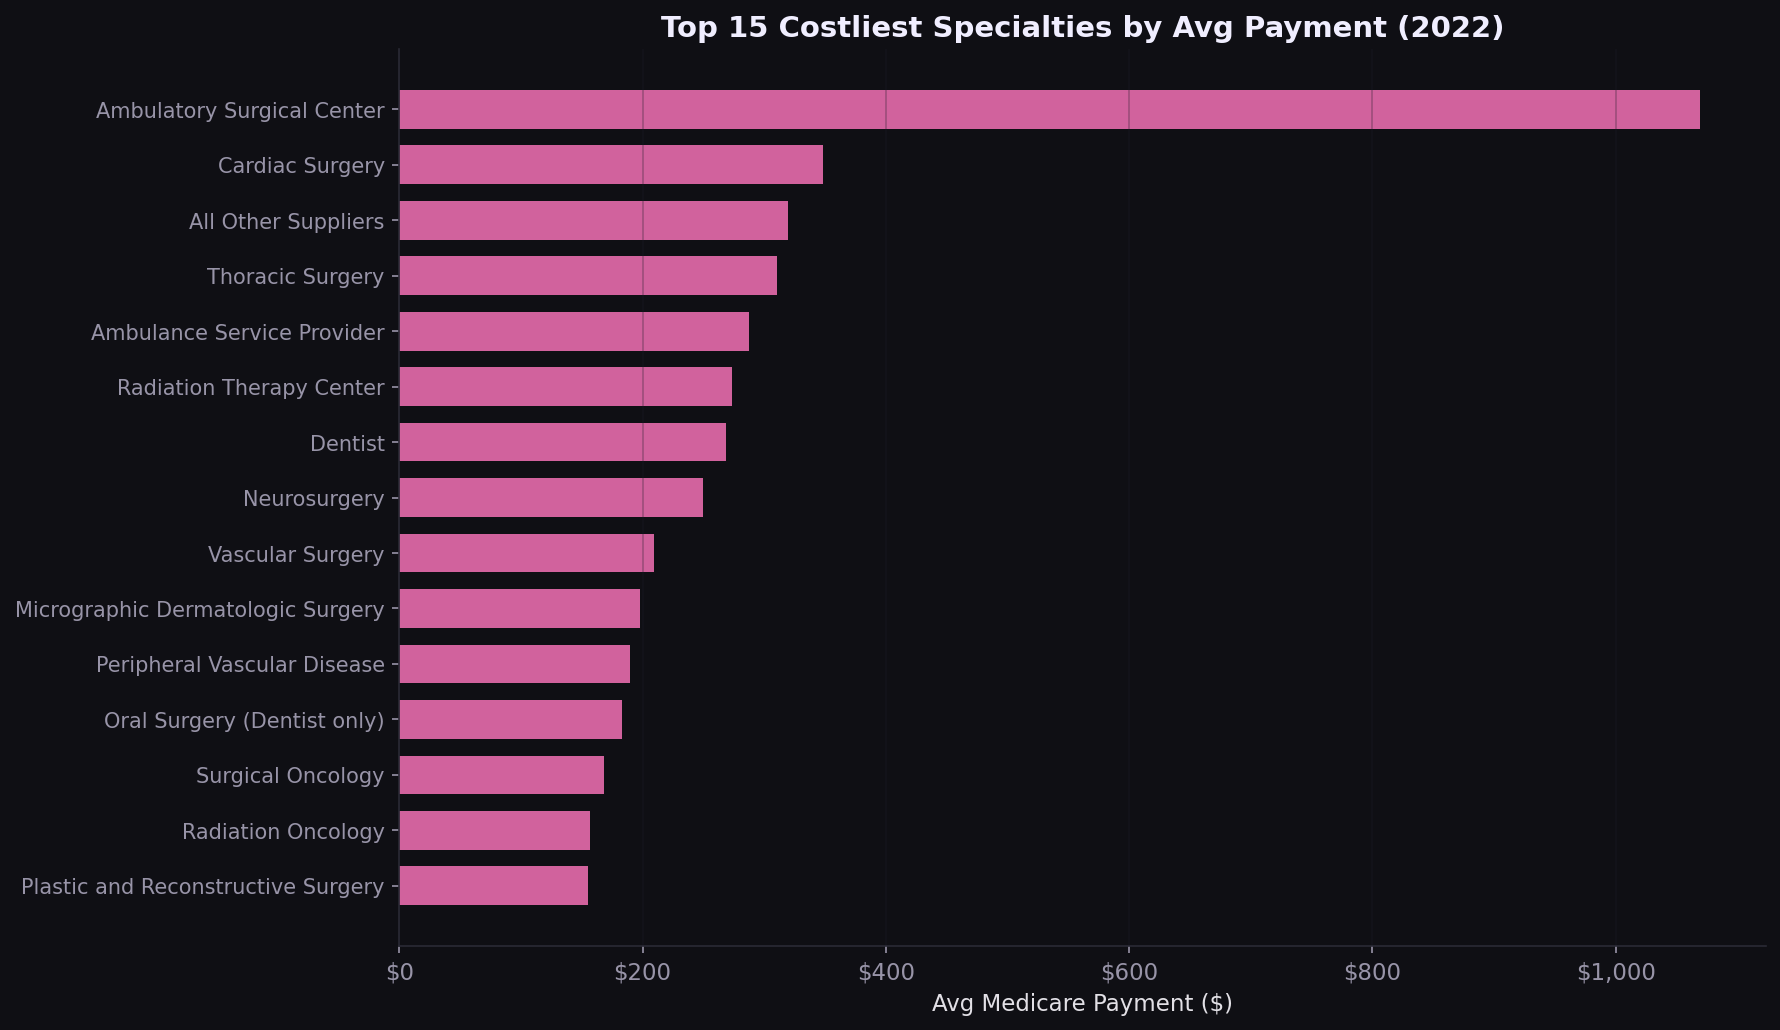

In [11]:
display(Image(filename=str(FIGURES / 'top15_specialty_cost.png')))

**Takeaway:** The volume-cost mismatch by specialty is a signal for payers. High-volume/low-cost specialties (like lab and radiology) drive spend through utilization; high-cost specialties (like surgery) drive spend through unit price. Different levers apply: utilization management for the former, rate negotiation for the latter.

---
## 7. Physician markup and rate variation

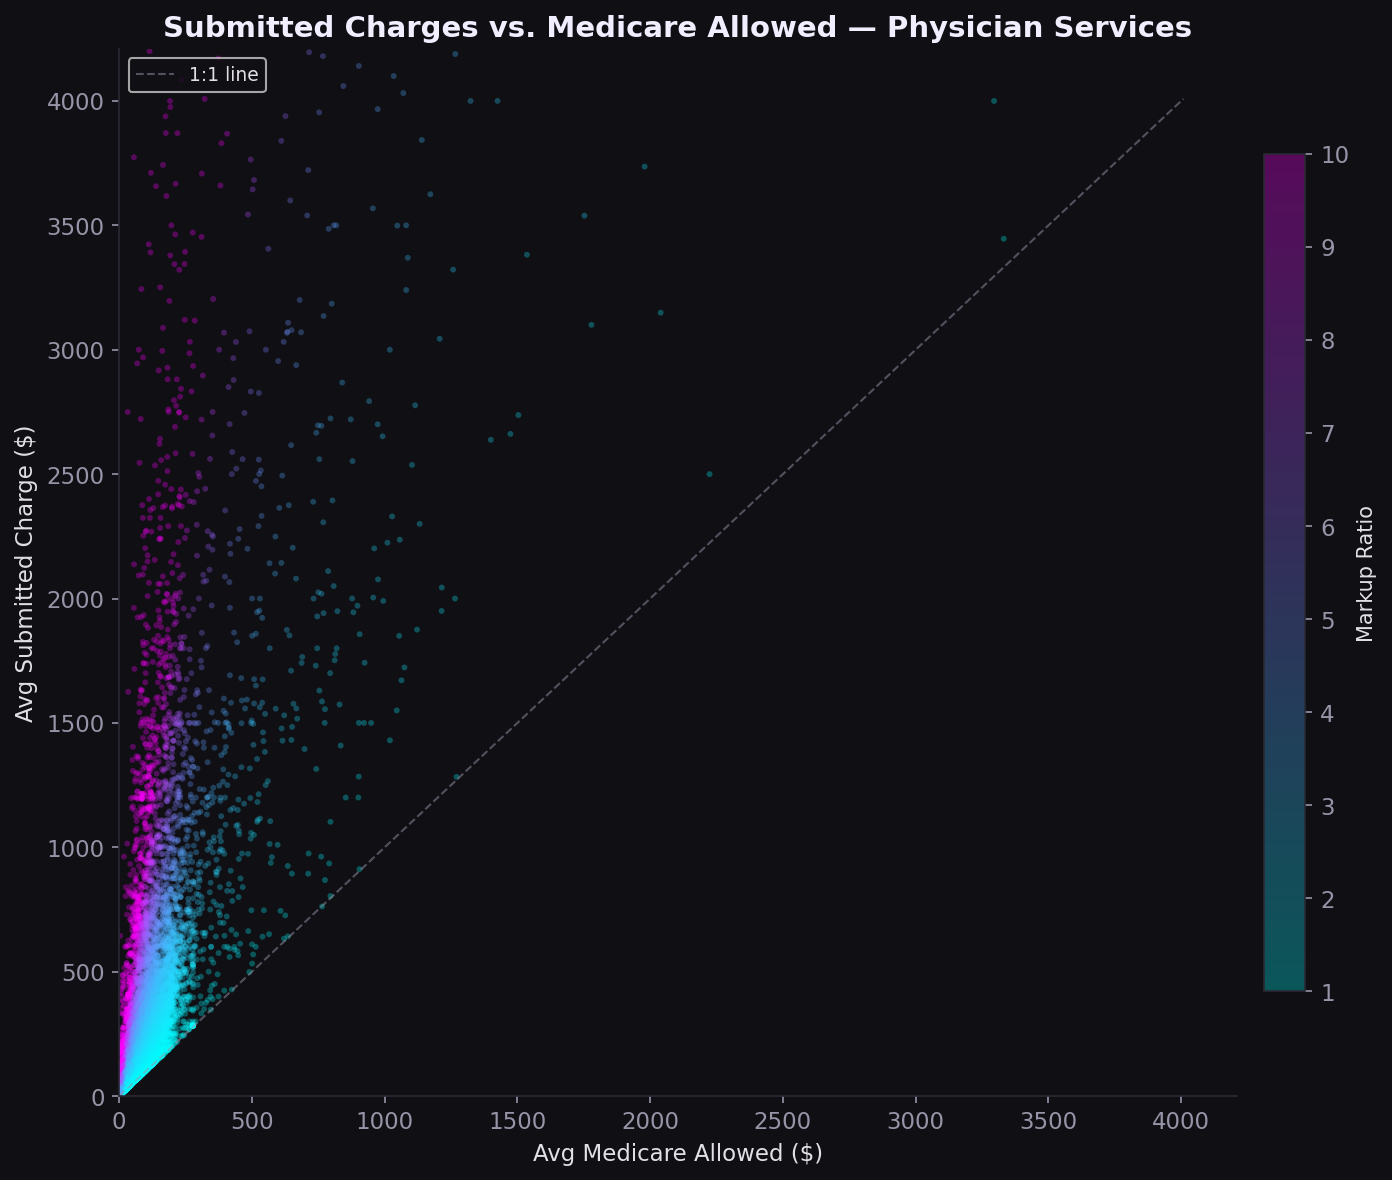

In [12]:
display(Image(filename=str(FIGURES / 'physician_charges_vs_allowed.png')))

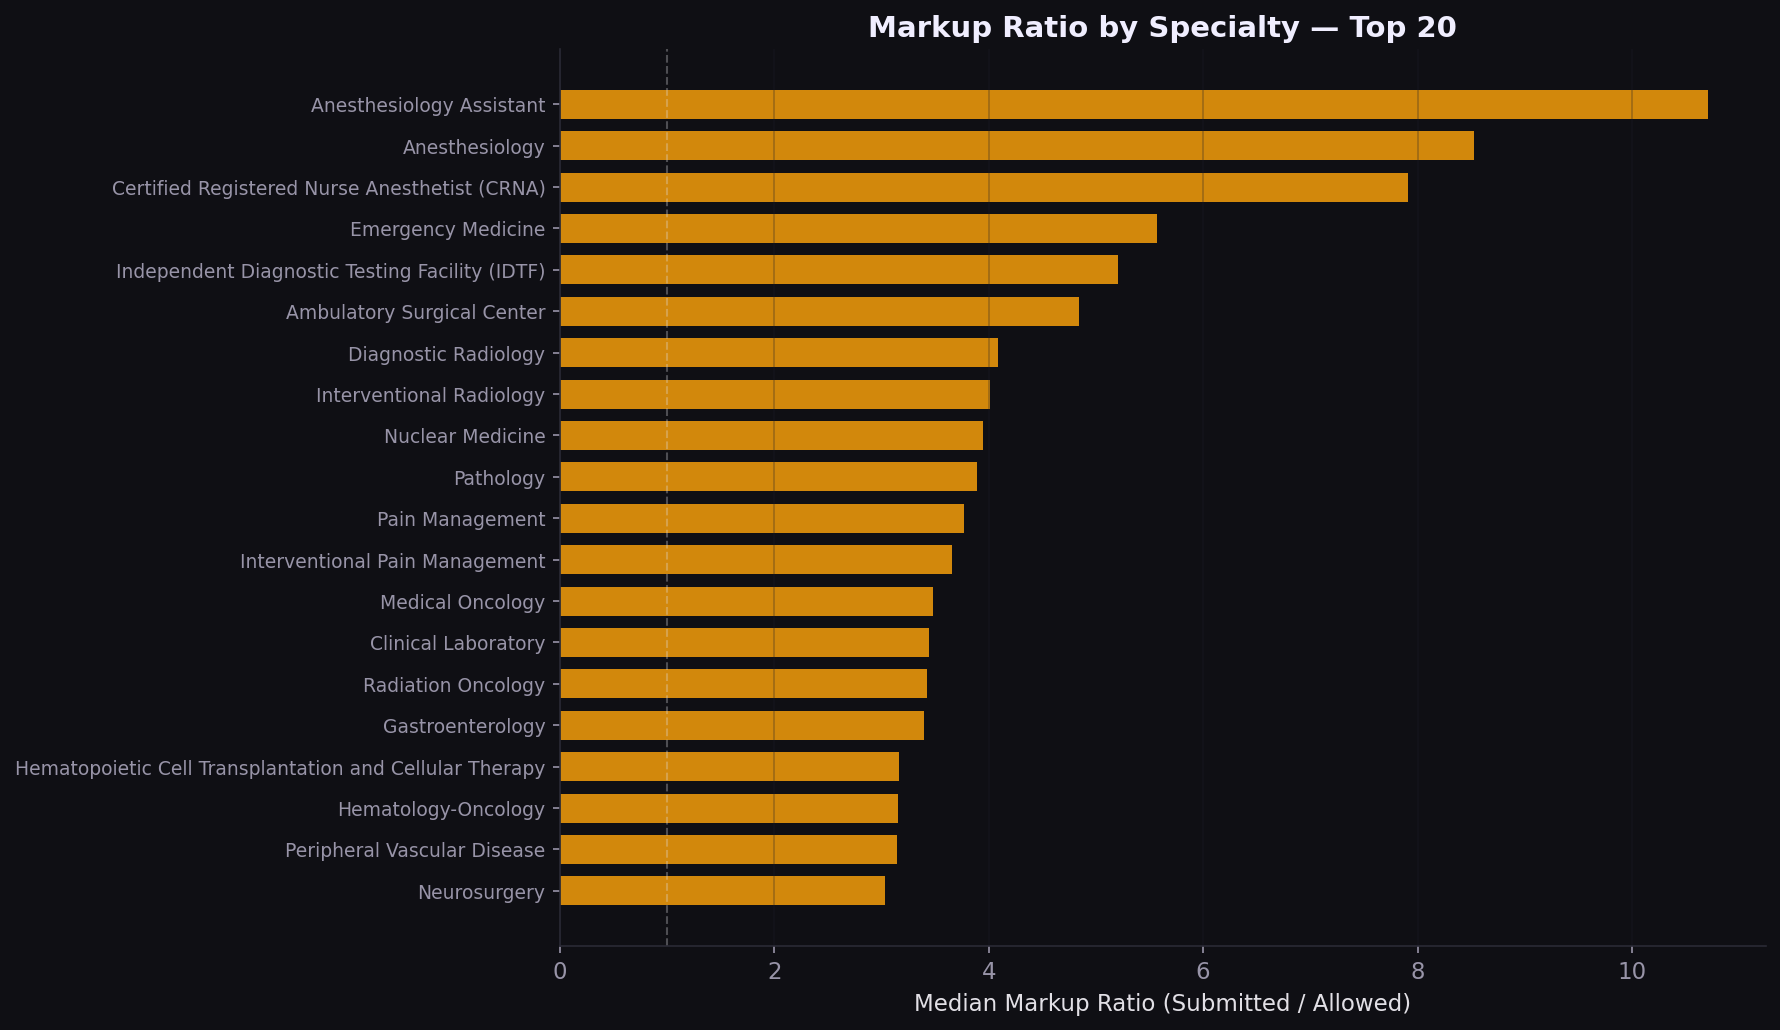

In [13]:
display(Image(filename=str(FIGURES / 'specialty_markup_ratio.png')))

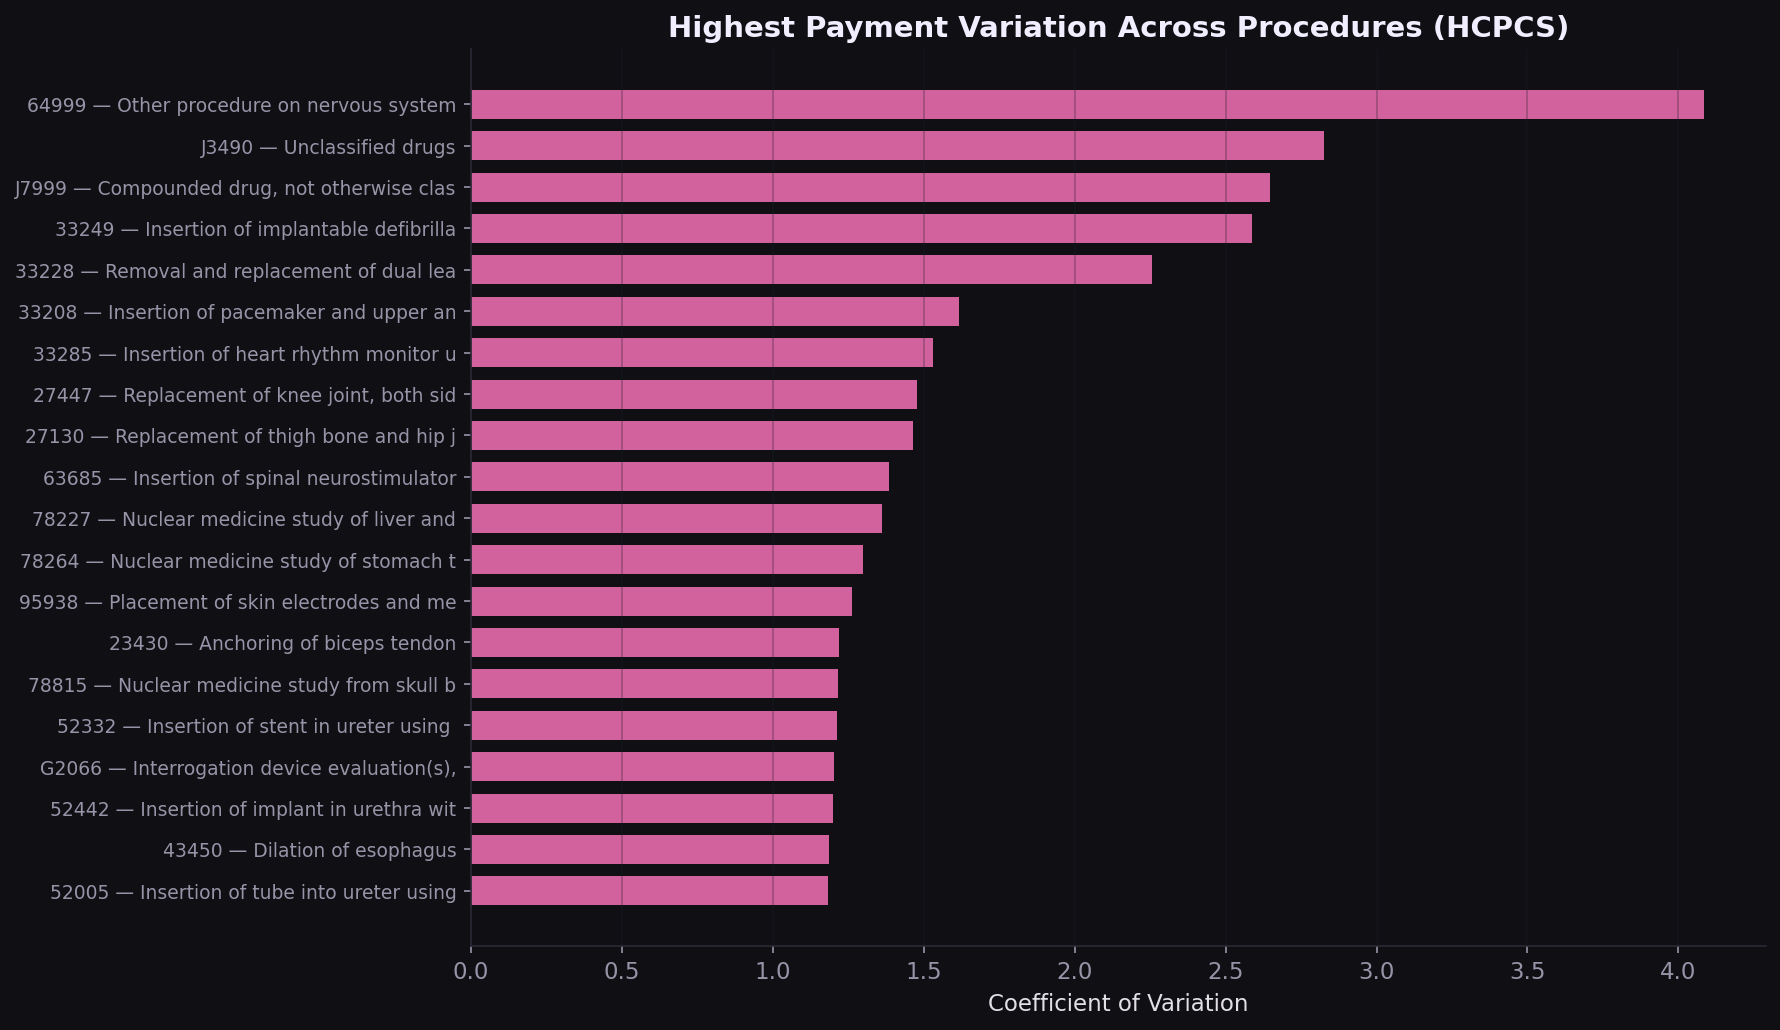

In [14]:
display(Image(filename=str(FIGURES / 'hcpcs_payment_variation.png')))

**Takeaway:** The HCPCS-level coefficient of variation chart identifies specific procedures where payment varies most across providers. These are the line items where payer benchmarking tools can surface outliers and drive standardization.

---
## 8. Geographic rate spread: physician services

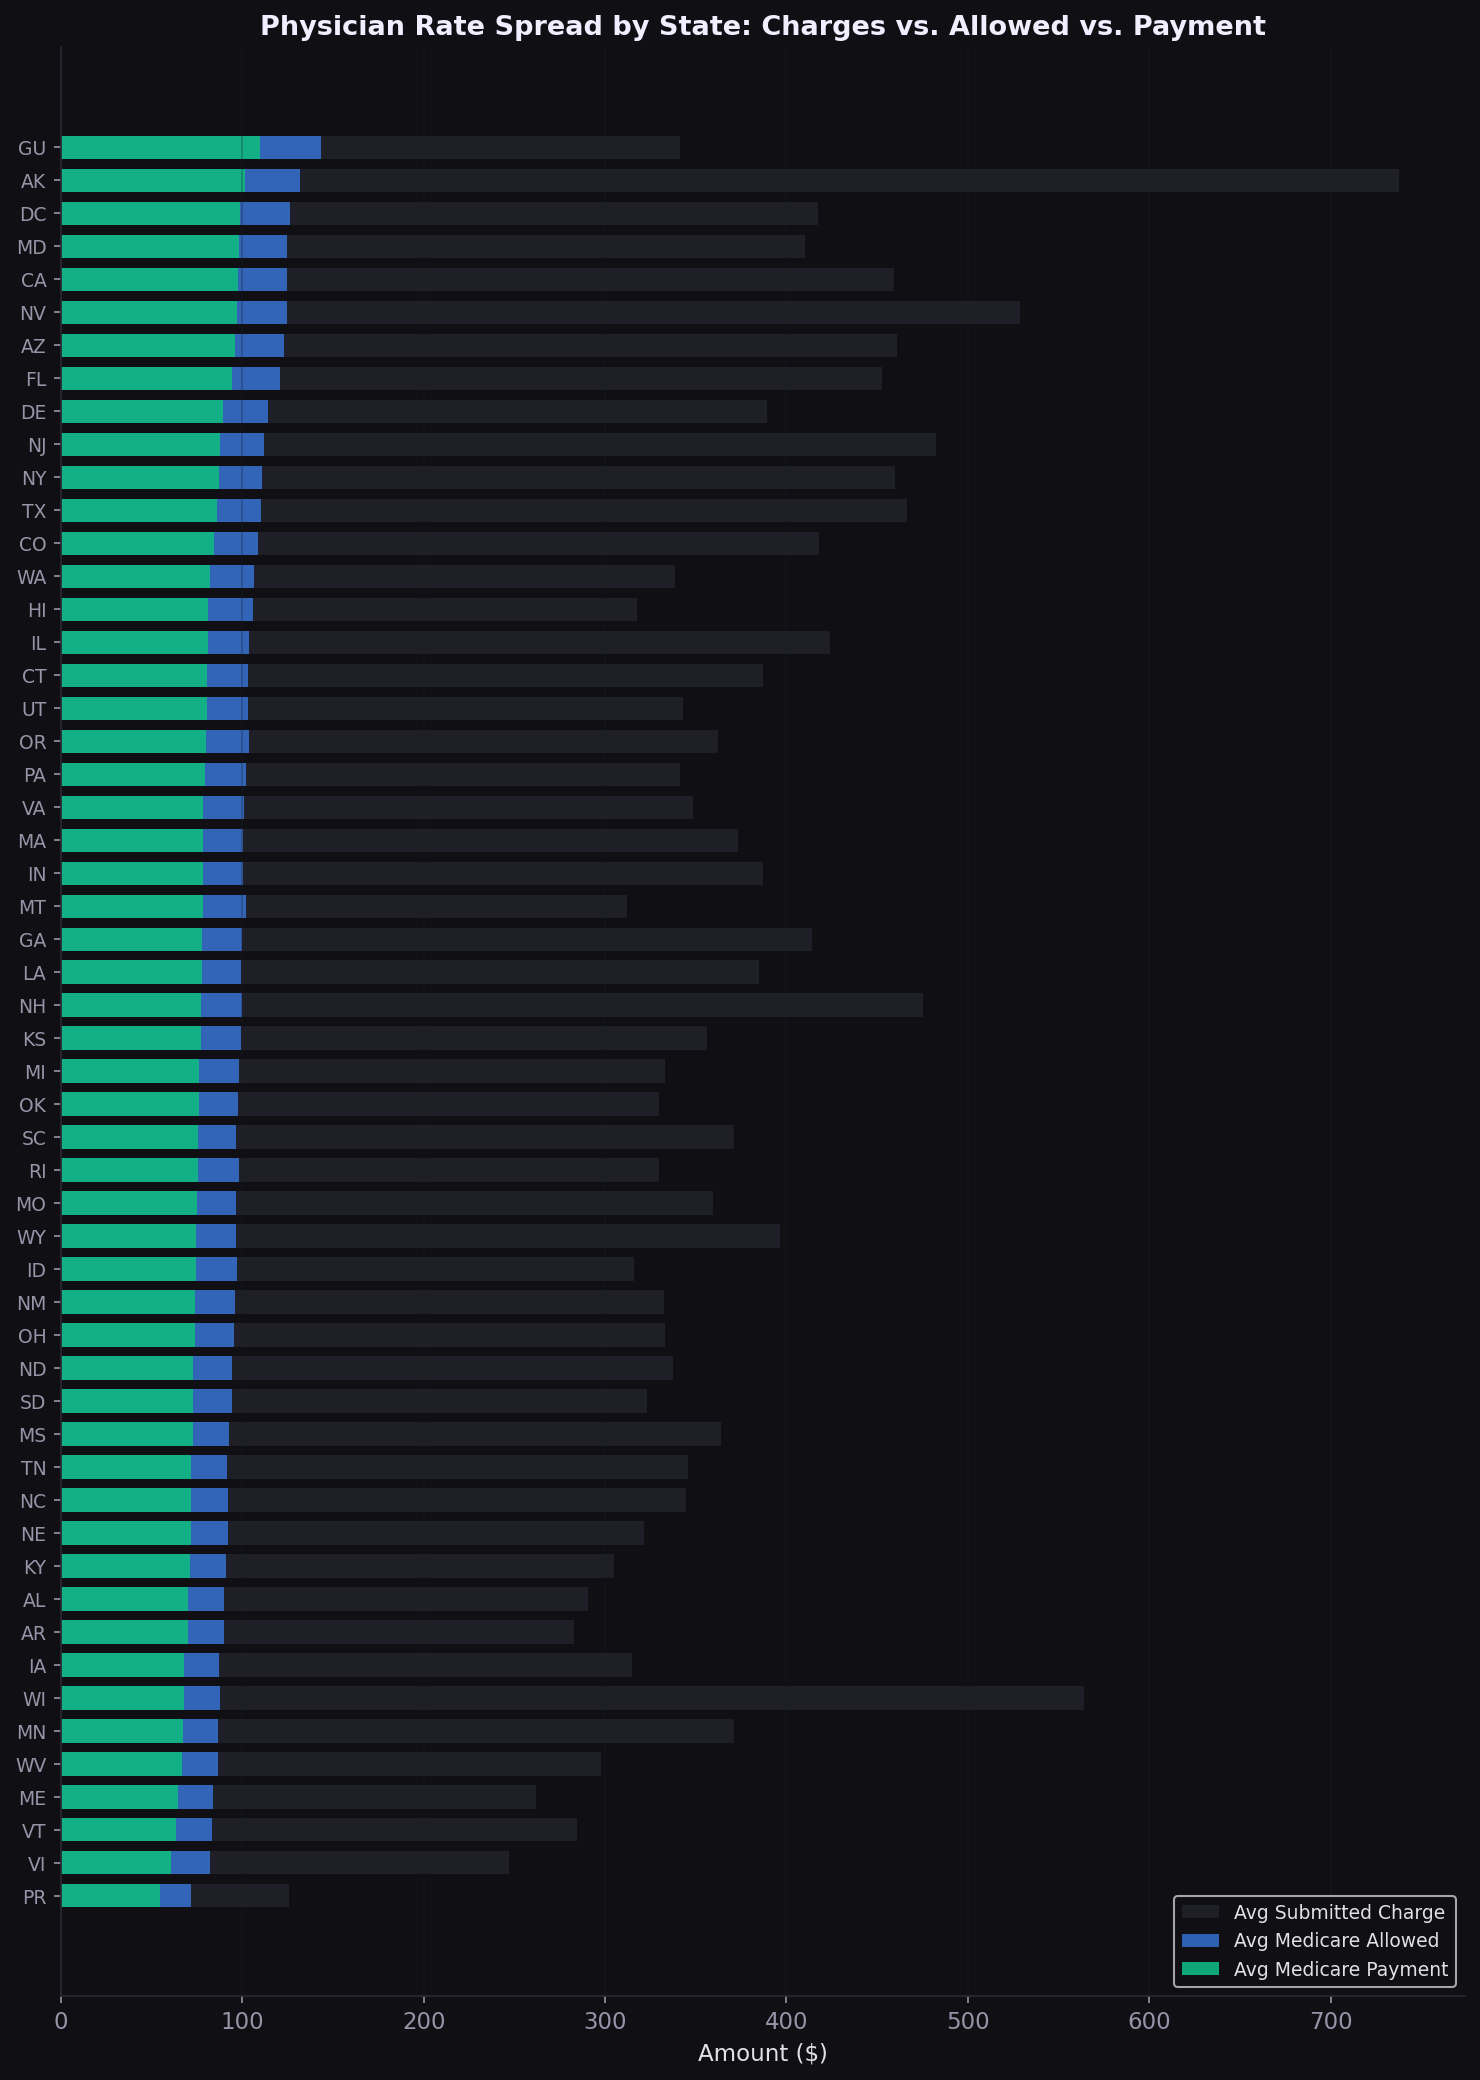

In [15]:
display(Image(filename=str(FIGURES / 'state_physician_rate_spread.png')))

**Takeaway:** The three-layer bar chart (charge, allowed, payment) shows that the gap between submitted charges and Medicare's allowed amount is consistent across states, but the absolute levels vary. States where both charges and payments are high (e.g., CA, NY, NJ) represent the largest dollar-opportunity for commercial payers benchmarking against Medicare.

---
## Implications for Payer Strategy

| Finding | Strategic Implication |
|---------|---------------------|
| Septicemia = 11% of inpatient volume | Bundled payment and readmission reduction programs should prioritize sepsis pathways |
| Median inpatient markup = 5.4x | Chargemaster-based contracts systematically overpay relative to Medicare; percent-of-Medicare benchmarks are more defensible |
| MD vs. NV markup spread = 9.5x | State regulatory environment is a first-order variable in rate strategy; multi-state payers need state-specific playbooks |
| High-variation HCPCS codes | Procedure-level rate benchmarking can identify outlier providers billing 3-5x peers for the same service |
| Volume-cost specialty mismatch | Utilization management for high-volume specialties; rate negotiation for high-cost specialties |

---

## Methods

- **Data:** CMS Medicare Provider Utilization and Payment PUF, Calendar Year 2022
- **Inpatient file:** 145,742 provider-DRG records across 3,015 hospitals and 533 DRGs
- **Physician file:** 9.76M provider-HCPCS records across 1.15M NPIs and 6,326 procedure codes
- **Cleaning:** Deduplication on natural keys, encoding normalization (Latin-1), US-only filter for physician file
- **Derived variable:** Markup ratio = submitted charges / Medicare payment (inpatient) or submitted charges / Medicare allowed (physician)
- **Tools:** Python, pandas, matplotlib

---

*Analysis by Sridharan Gopalsamy Ramaswamy | MPH/MBA, Washington University in St. Louis*